# Tutorial 2 — Spectroscopy: AB Pic b

**What you'll learn:** Fitting a medium-resolution K-band spectrum with ForMoSA v2.0.
Compared to Tutorial 1 (photometry), spectroscopy adds *resolution adaptation* —
the model grid must be convolved to match your instrument's spectral resolution —
and allows you to constrain the companion's **radial velocity**.

**Target:** AB Pictoris b — a young (~30 Myr), directly-imaged planetary-mass companion
at ~50 pc orbiting the debris-disk star AB Pic. It is one of the benchmarks for
atmosphere retrieval codes because of its well-characterised orbit and known distance.

**Data:** VLT/SINFONI K-band spectrum (R ≈ 4000, λ = 2.0–2.45 µm).
Published in [Palma-Bifani et al. (2023, A&A, 670, A90)](https://ui.adsabs.harvard.edu/abs/2023A%26A...670A..90P/abstract).

**Grid:** BT-Settl (same grid downloaded in Tutorial 1)

**Estimated runtime:**
- Grid adaptation: < 30 s
- Nested sampling (200 live points, nestle): ~3 min

**References:** [Palma-Bifani et al. (2023, A&A, 670, A90)](https://ui.adsabs.harvard.edu/abs/2023A%26A...670A..90P/abstract)


## Section 0: Setup

Run these four cells before anything else. They check your environment, create the working directories, download the observation data, and download the model grid.

In [4]:
# Environment check
import sys
try:
    import ForMoSA
    print(f"ForMoSA {ForMoSA.__version__} — OK")
except ImportError:
    raise ImportError("pip install ForMoSA && conda install dask netCDF4 bottleneck")
print(f"Python {sys.version.split()[0]}")


ForMoSA 2.0.0 — OK
Python 3.11.13


In [5]:
# Workspace setup
from pathlib import Path
TUTORIAL_DIR = Path(".").resolve()
for d in ["data", "adapted_grid", "results", "grid"]:
    (TUTORIAL_DIR / d).mkdir(exist_ok=True)
print(f"Working directory: {TUTORIAL_DIR}")


Working directory: /Users/rajpoot/Karmabhumi/Packages/ForMoSA/docs/tutorials/spectroscopy/abpicb


In [6]:
# Data download + validation
import urllib.request
from astropy.io import fits

DATA_FILE = TUTORIAL_DIR / "data" / "ABPicb_SINFONI_K.fits"
DATA_URL  = (
    "https://github.com/exoAtmospheres/ForMoSA/releases/download/"
    "tutorial-data-v1/ABPicb_SINFONI_K.fits"
)

if not DATA_FILE.exists():
    print("Downloading observation data...")
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
    print("Done.")
else:
    print(f"Data already present: {DATA_FILE.name}")

# Validate required data keys. Support two FITS layouts:
# 1) Multiple HDUs named WAV/FLX/ERR/...
# 2) A single BINTable HDU with columns WAV/FLX/ERR/...
REQUIRED = {"WAV", "WAVE_UNIT", "FLX", "ERR", "FAC", "INS", "RES"}
with fits.open(DATA_FILE) as hdul:
    ext_names = {hdu.name.upper() for hdu in hdul[1:] if getattr(hdu, "name", None)}

    # Find first table HDU with columns, if any
    table_hdu = next(
        (hdu for hdu in hdul[1:] if hasattr(hdu, "columns") and hdu.columns is not None),
        None,
    )
    table_cols = ({name.upper() for name in table_hdu.columns.names} if table_hdu is not None else set())

# Prefer table-column validation when present; otherwise validate extension names
available = table_cols if table_cols else ext_names
missing = REQUIRED - available
if missing:
    mode = "table columns" if table_cols else "FITS extensions"
    raise RuntimeError(
        f"Missing required {mode}: {sorted(missing)}. "
        f"Found: {sorted(available)}"
    )

print("\nValidation source:", "BINTable columns" if table_cols else "FITS extensions")
print("Required keys (marked ✓):")
for name in sorted(available):
    mark = "✓" if name in REQUIRED else " "
    print(f"  {mark} {name}")
print("\nAll required keys present — data is valid.")


Data already present: ABPicb_SINFONI_K.fits

Validation source: BINTable columns
Required keys (marked ✓):
  ✓ ERR
  ✓ FAC
    FILT
  ✓ FLX
  ✓ INS
  ✓ RES
  ✓ WAV
  ✓ WAVE_UNIT

All required keys present — data is valid.


In [7]:
# Grid download
# The full BT-Settl grid is ~1 GB. Once downloaded, keep it —
# it works for all ForMoSA tutorials and your own science.
import urllib.request

GRID_FILE = TUTORIAL_DIR / "grid" / "BT-Settl.nc"
GRID_URL  = "https://drive.usercontent.google.com/download?id=1wvf4A-DupdVnYIpK_HmHE-fobqnYtvEz&export=download&confirm=t"

# Override GRID_FILE here if you already have the grid elsewhere:
# GRID_FILE = Path("/path/to/your/BT-Settl.nc")

if not GRID_FILE.exists():
    print("Downloading BT-Settl model grid (~1 GB). This takes a few minutes.\n")
    try:
        from tqdm import tqdm
        class _Progress(tqdm):
            def update_to(self, b=1, bs=1, ts=None):
                if ts: self.total = ts
                self.update(b * bs - self.n)
        with _Progress(unit="B", unit_scale=True, desc="BT-Settl.nc") as t:
            urllib.request.urlretrieve(GRID_URL, GRID_FILE, reporthook=t.update_to)
    except ImportError:
        def _progress(count, bs, total):
            pct = min(100, count * bs / total * 100)
            print(f"\r  {pct:.1f}%  {count*bs/1e6:.1f}/{total/1e6:.1f} MB",
                  end="", flush=True)
        urllib.request.urlretrieve(GRID_URL, GRID_FILE, reporthook=_progress)
        print()
    print(f"\nSaved: {GRID_FILE}")
else:
    print(f"Grid already present: {GRID_FILE.name}")

import xarray as xr
grid = xr.open_dataset(GRID_FILE, decode_cf=False)
par_names = grid.attrs.get("par", [])
par_units = grid.attrs.get("unit", [])
print(f"\nGrid dimensions: {dict(grid.sizes)}")
for i, (key, name, unit) in enumerate(zip(["par1", "par2", "par3", "par4"],
                                           par_names or ["par1","par2","par3","par4"],
                                           par_units or ["","","",""])):
    if key in grid.coords:
        vals = grid[key].values
        print(f"  {name} {unit}: {vals[0]:.1f} → {vals[-1]:.1f}  ({len(vals)} points)")

# Display the grid content in a notebook
# Click on the data repo icon (on the right) to show the full content if needed
grid

Grid already present: BT-Settl.nc

Grid dimensions: {'wavelength': 1161983, 'par1': 22, 'par2': 7}
  teff (K): 1200.0 → 2900.0  (22 points)
  logg (dex): 2.5 → 5.5  (7 points)


<xarray.Dataset>
Dimensions:     (wavelength: 1161983, par1: 22, par2: 7)
Coordinates:
  * wavelength  (wavelength) float64 0.3001 0.3001 0.3001 ... 30.0 30.0 30.0
  * par1        (par1) float64 1.2e+03 1.3e+03 1.4e+03 ... 2.8e+03 2.9e+03
  * par2        (par2) float64 2.5 3.0 3.5 4.0 4.5 5.0 5.5
Data variables:
    grid        (wavelength, par1, par2) float64 ...
Attributes:
    key:      ['par1', 'par2']
    par:      ['teff', 'logg']
    title:    ['Teff', 'log(g)']
    unit:     ['(K)', '(dex)']
    res:      [ 60003.04331194  60004.04327964  60005.04321604 ... 149994.483...

## Section 1: The science

### Spectroscopy vs photometry

Photometry gives you broad-band colours. A medium-resolution spectrum gives you
the *shape* of molecular absorption features — CO overtone bands at 2.29–2.45 µm,
H₂O bands, and more. This makes spectroscopy far more sensitive to Teff and log g,
and crucially, it allows you to measure the **radial velocity (RV)** of the companion
by cross-correlating the observed features against the model.

### Why no vsini?

To measure rotational broadening (vsini) reliably, you need R > 50,000 so that
individual rotational lines are resolved. SINFONI K-band delivers R ≈ 4000 — enough
for molecular features but not for vsini. We therefore fit `rv` but not `vsini`.
(Tutorial 3 covers vsini with VLT/HiRISE at R ≈ 140,000.)

### AB Pic b

AB Pic b is a ~13 MJup companion at a projected separation of ~275 au, co-moving
with the β Pic moving group (age ≈ 20–30 Myr). Its low surface gravity and warm
temperature make it an L-type object with prominent CO and H₂O absorption.
Literature values: Teff ≈ 1700 K, log g ≈ 4.0, d = 50.1 pc (Hipparcos).


## Section 2: Inspect the data

Wavelength range : 1.9530 – 2.4472 µm
Number of points : 2018
Resolution R     : 5090 ± 0  (mean ± std)


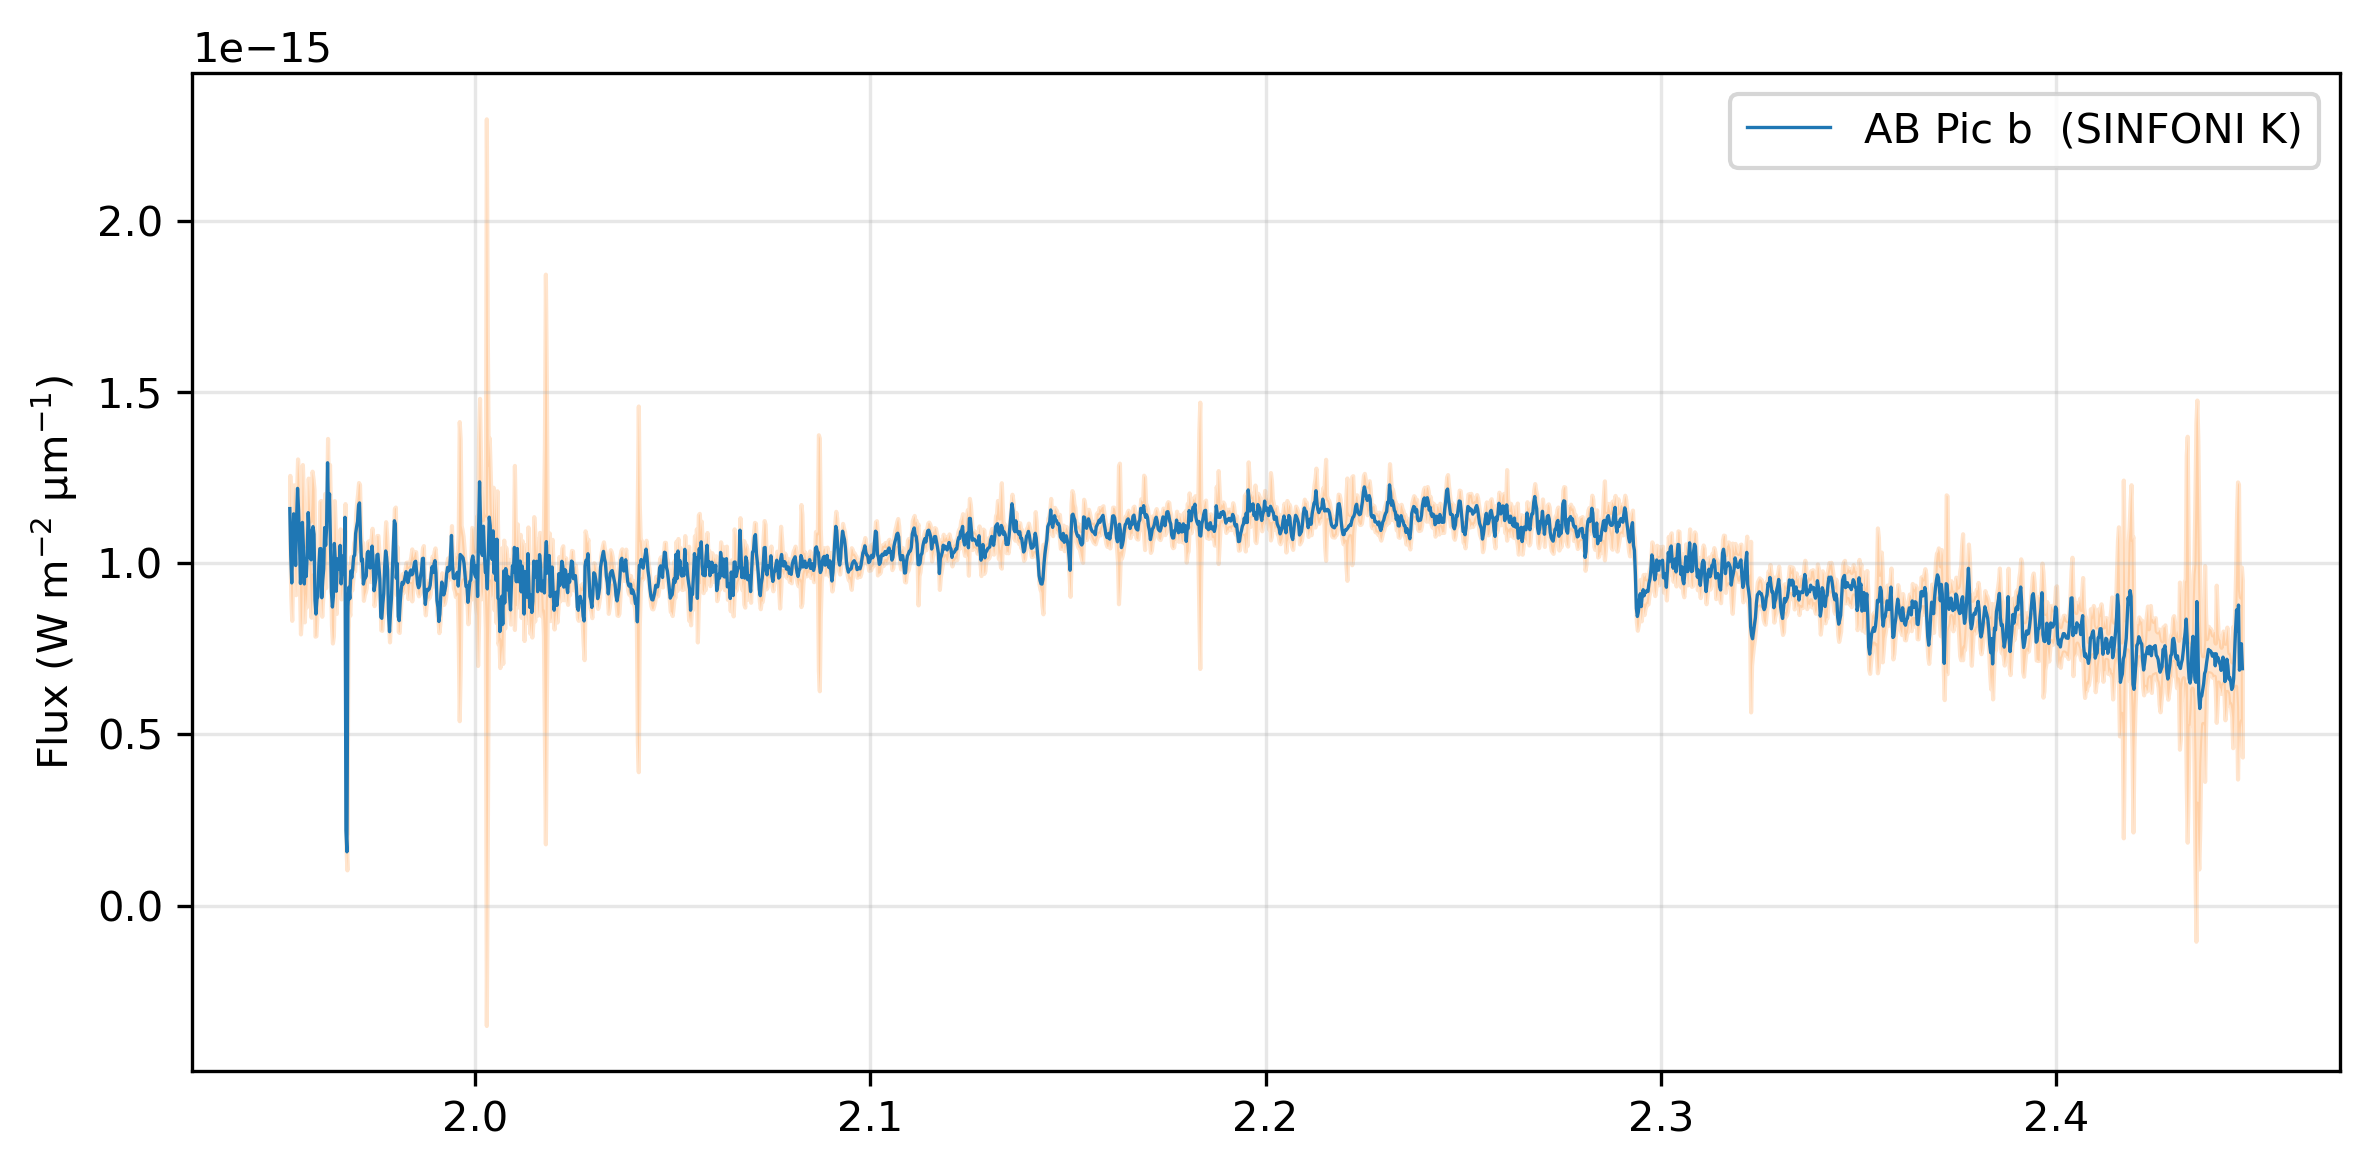

In [8]:
from astropy.table import Table
import matplotlib.pyplot as plt

table = Table.read(DATA_FILE, format="fits")
wav  = table["WAV"].data.astype(float)       # wavelength (µm)
flx  = table["FLX"].data.astype(float)       # flux (W/m²/µm)
err  = table["ERR"].data.astype(float)       # 1-σ uncertainty
fac  = table["FAC"].data                     # facility names
ins  = table["INS"].data                     # instrument names
res  = table["RES"].data.astype(float)       # spectral resolution R = λ/Δλ

print(f"Wavelength range : {wav.min():.4f} – {wav.max():.4f} µm")
print(f"Number of points : {len(wav)}")
print(f"Resolution R     : {res.mean():.0f} ± {res.std():.0f}  (mean ± std)")

fig, ax = plt.subplots(figsize=(8, 4), sharex=True, dpi=300)
ax.plot(wav, flx, color="C0", lw=0.8, label="AB Pic b  (SINFONI K)")
ax.fill_between(wav, flx - err, flx + err, color="C1", alpha=0.2)
ax.set_ylabel(r"Flux (W m$^{-2}$ µm$^{-1}$)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout();

## Section 3: Configure the analysis

### Part A: Setting up the configurations

ForMoSA v2.0 uses four Python dataclasses to configure a run. Each dataclass
groups related settings — you only need to set the ones that differ from the defaults.

| Dataclass | Controls |
|-----------|----------|
| `ConfigPath` | File paths (observation, grid, output directories) |
| `ConfigAdapt` | How the grid is resampled to match the observations |
| `ConfigInversion` | Wavelength fitting window, nested sampling algorithm |
| `ConfigParameters` | Prior on each free parameter |
| `Config_NS` | Settings for Nested Sampling Algorithms |


In [9]:
from ForMoSA.config.global_config import ConfigPath, ConfigAdapt, ConfigInversion, ConfigParameters, Config_NS, ConfigPyMultiNest

# ──────────────────────────── Paths ────────────────────────────
config_path = ConfigPath(
    observation_path=[str(DATA_FILE)],
    adapt_store_path=str(TUTORIAL_DIR / "adapted_grid"),
    result_path=str(TUTORIAL_DIR / "results"),
    model_path=str(GRID_FILE),
)

# ────────────────────────── Adaptation ──────────────────────────
config_adapt = ConfigAdapt()

# you can also try different adaptation settings to see how they affect the fit. For example:
# res_cont=500 tells ForMoSA to remove the continuum using a low-pass filter
# at R=500 before comparing model to data. This removes broad-band slope
# differences and lets the fit focus on molecular features.
# config_adapt = ConfigAdapt(
#     res_cont = 500,                 # enable continuum removal at R=500
#     wav_cont = ["2.0, 2.45"],       # only use K-band for continuum fit (same as wav_fit below)
# )


# ─────────────────────────── Inversion ──────────────────────────
config_inversion = ConfigInversion(
    wav_fit   = ["2.0, 2.45"],      
    ns_algo   = "pymultinest",           # nested sampling algorithm to use
    npoints   = 100,                # more live points for better posterior sampling
    logL_type = ["chi2"],
)

# ────────────────────────── Parameters ──────────────────────────
# Syntax for priors: ["type", "min", "max"] or ["constant", "value"]
# par1 = Teff (K), par2 = log g (dex) — read from grid attributes above
config_params = ConfigParameters(
    par1 = ["uniform", "1200", "2900"],     # Teff (K)
    par2 = ["uniform", "2.5", "5.5"],       # log g (dex)
    rv   = ["uniform", "-100", "100"],      # radial velocity (km/s)
)

# ───────────────────── Nested Sampling Algo ───────────────────────
# Initialize the nested sampling configuration with the chosen algorithm (here, pymultinest)
config_ns = Config_NS(pymultinest=ConfigPyMultiNest())


# Display the configuration for verification
print("Configuration:")
print(f"  wav_fit : {config_inversion.wav_fit[0]} µm")
print(f"  Free    : {config_params.par1[1]} - {config_params.par1[2]} (Teff), {config_params.par2[1]} - {config_params.par2[2]} (log g), {config_params.rv[1]} - {config_params.rv[2]} (rv)")

Configuration:
  wav_fit : 2.0, 2.45 µm
  Free    : 1200 - 2900 (Teff), 2.5 - 5.5 (log g), -100 - 100 (rv)


### Saving the configuration for later reference

In [10]:
# Saving the configuration for later reference
from ForMoSA.config.global_config import ConfigGenerator  

# Initialize the generator
generator = ConfigGenerator()
  
# Create a dictionary of your configuration objects  
generator.config.update({
    "config_path": config_path,
    "config_adapt": config_adapt,
    "config_inversion": config_inversion,
    "config_parameters": config_params,
    "config_ns": config_ns,
})
  
# Save to an .ini file  
generator.save(path=TUTORIAL_DIR, name="spectro_config.ini")

INFO         Save config to path /Users/rajpoot/Karmabhumi/Packages/ForMoSA/docs/tutorials/spectroscopy/abpicb

### Loading of the configuration file

If you are just using the configuration file, then you have to load it first so that it can be passed to all algorithms. The Nested Sampling class will use only the parameters relevant to the algorithm you are using.

In [11]:
from ForMoSA.config.global_config import ConfigLoader, Config_NS

# Load the configuration from the .ini file we just saved
cfg = ConfigLoader(str(TUTORIAL_DIR/'spectro_config.ini'))
sections = cfg.load()

# Extract the individual configuration sections
config_path = sections.get("config_path")
config_adapt = sections.get("config_adapt")
config_inversion = sections.get("config_inversion")
config_params = sections.get("config_parameters")

# Initialize Config_NS (required for nested sampling) with the loaded configuration sections
config_ns = Config_NS(
                nestle=cfg.config['config_nestle'],
                pymultinest=cfg.config['config_pymultinest'],
                ultranest=cfg.config['config_ultranest']
            )

INFO         Config file loaded

### Step B: Setting up the Analysis object

Analysis object is the main interface to run the ForMoSA using the provided configuration. It allows you to run the adaptation and inversion steps, or skip them if already done, and proceed directly to plotting results.

<div class="alert alert-block alert-warning"> 

<b>NOTE:</b> Here we create the main analysis class. For the purpose of not overcharging the notebook, we use log_level = 'error'.

The different options are:
<ul>
    <li> 'info': basic information
    <li> 'debug': basic information + additional debugging information
    <li> 'warning': only warning messages
    <li> 'error': only error messages, so typically no message unless you have an error in the code
    <li> 'critical': same thing as 'error' but for critical ones
    <li> 'off' or None: no logging
</ul>
</div>


In [12]:
from ForMoSA import Analysis

# If this is the first time you are adapting your model grid, or if you need to re-adapt it, set adapted = False
# If you have already adapted your model grid, set adapted = True
adapted = False

# If you want to perform the fit, set fitted = False
# If you only want to generate plots, set fitted = True
fitted = False

# Initialize the Analysis object with the loaded configuration sections and control flags
analysis = Analysis(config_path, adapted=adapted, fitted=fitted, log_level='error')

## Section 4: Adapt the grid

The grid is pre-computed at native model resolution. Before fitting, ForMoSA *adapts* it: it evaluates the model flux through your spectroscopic observation, producing a much smaller grid of model spectra that is directly comparable to your observations.

For spectroscopy, adaptation can take some time depending upon how big your grid is and how high the spectral resolution of your data is.

Set `adapted=True` on subsequent runs to skip this step and load the cached grid.


In [13]:
if not adapted:
    # Adaptation convolves each model spectrum to match the SINFONI resolution
    # and resamples it onto the observed wavelength grid.
    print("Adapting grid (convolution + resampling)...")
    analysis.adapt(config_adapt, config_inversion)
    print("Done. Set adapted=True to skip on re-runs.")
else:
    print("Skipping adaptation. Set adapted=False to re-run.")

Adapting grid (convolution + resampling)...


BT-Settl_[Paranal]_[SINFONI]_Spectroscopic: 100%|██████████| 154/154 [00:07<00:00, 20.63model/s]

Done. Set adapted=True to skip on re-runs.


## Section 5: Run the nested sampling fit

Nested sampling explores the prior volume and computes the Bayesian evidence (log Z) alongside the posterior distributions. In this tutorial, we will use **pymultinest** to run with more live points. This requires **pymultinest** to be installed locally. If not, then check the installation page for the instructions.

The `npoints=100` setting is a good starting point for a quick check. For publication-quality posteriors, use 300–500 live points.

In [14]:
if not fitted:
    print(f"Running {config_inversion.ns_algo} with {config_inversion.npoints} live points...")
    analysis.nested_sampling(config_params, config_adapt, config_inversion, config_NS=config_ns)
    print("\nFit complete.")
else:
    print("Skipping fit. Set fitted=False to run the fit.")

Running pymultinest with 100 live points...
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  100
 dimensionality =    3
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.914634
Replacements:                                150
Total Samples:                               164
Nested Sampling ln(Z):              -5589.657900
Importance Nested Sampling ln(Z):   -1000.323229 +/-  0.996947
Acceptance Rate:                        0.858369
Replacements:                                200
Total Samples:                               233
Nested Sampling ln(Z):              -2970.624022
Importance Nested Sampling ln(Z):    -978.806982 +/-  0.997852
Acceptance Rate:                        0.788644
Replacements:                                250
Total Samples:      

## Section 6: Results


ForMoSA produces four diagnostic plots saved to `results/`:

| File | Shows |
|------|-------|
| `corner.pdf` | Posterior distributions and pairwise correlations |
| `chains.pdf` | Sample chains and weights (convergence check) |
| `radar.pdf` | Radar diagram of median ± 1σ for each parameter |
| `best_fit.pdf` | Best-fit model vs. observed data + residuals |

======== Nested Sampling Summary ====================
LogZ = -780.800 ± 0.369

Posterior estimates (median ± 1 sigma interval)

Teff        :  1480.1777 -  1.4425 +  1.4013 [1478.7352, 1481.5790]  MAP=1479.5289
log(g)      :     2.7420 -  0.0160 +  0.0173 [2.7260, 2.7594]  MAP=2.7320
rv          :    20.6912 -  0.7133 +  0.9354 [19.9779, 21.6266]  MAP=20.9455


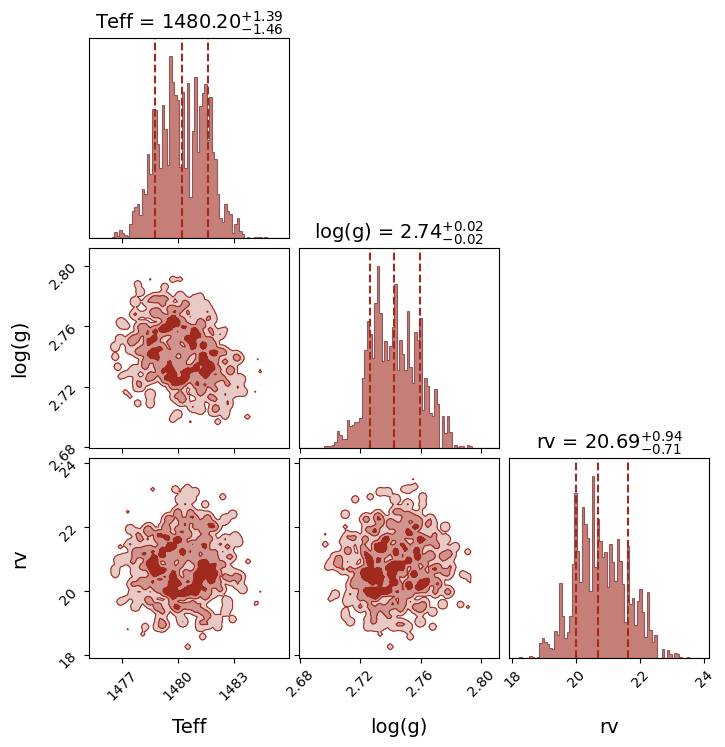

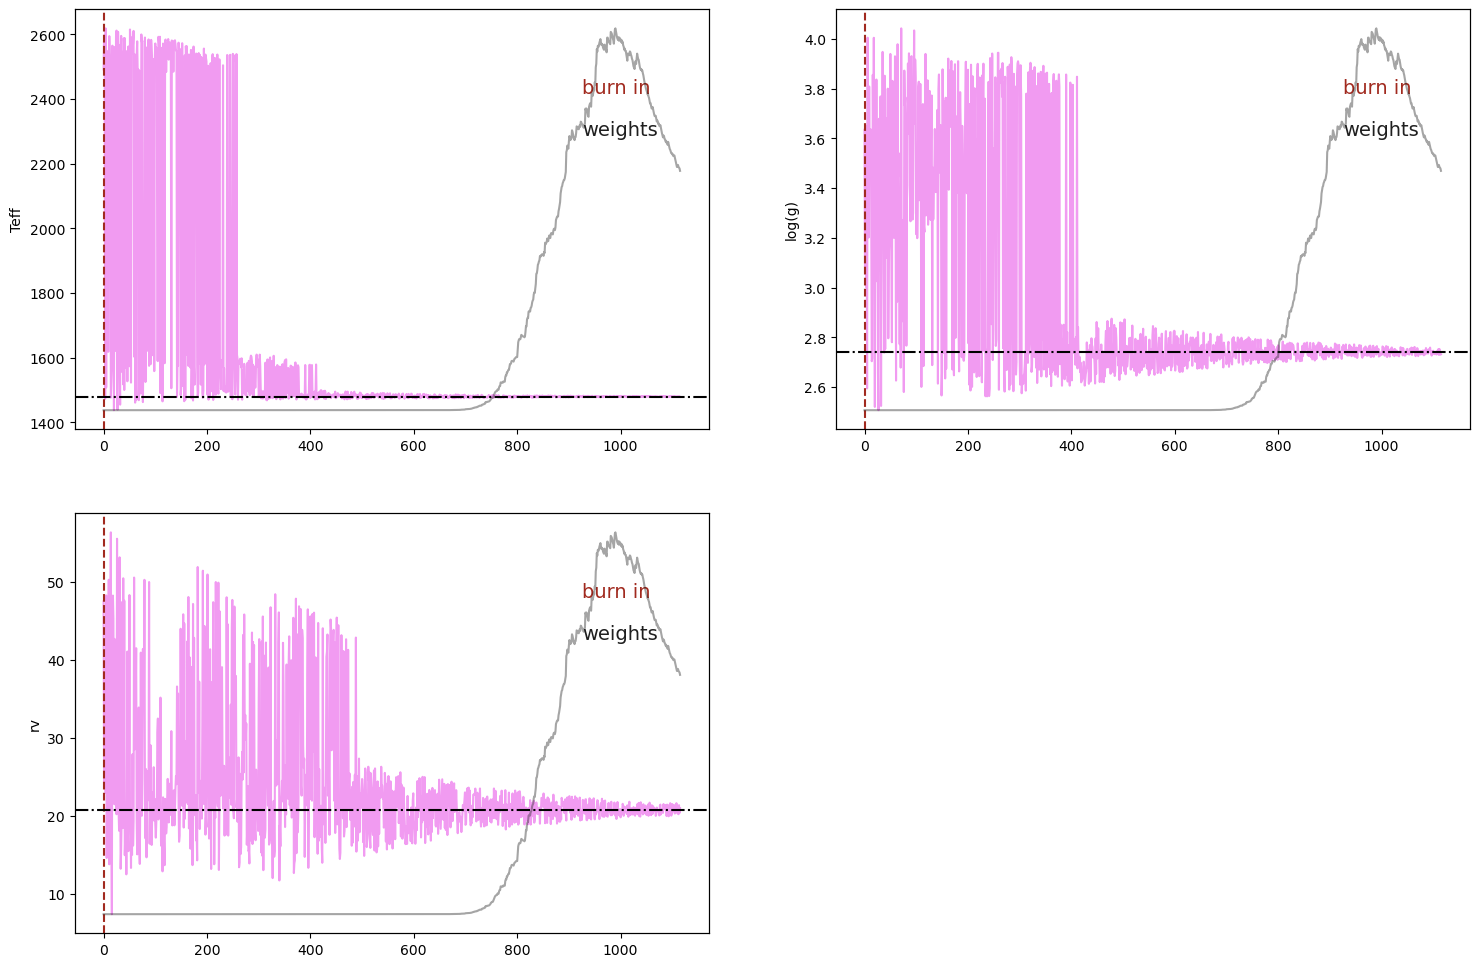

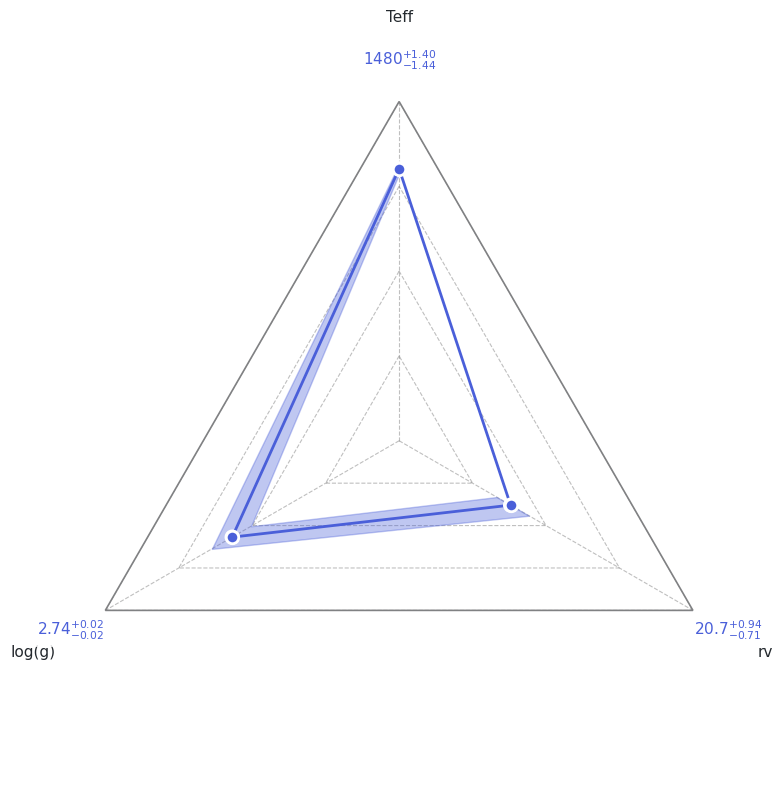

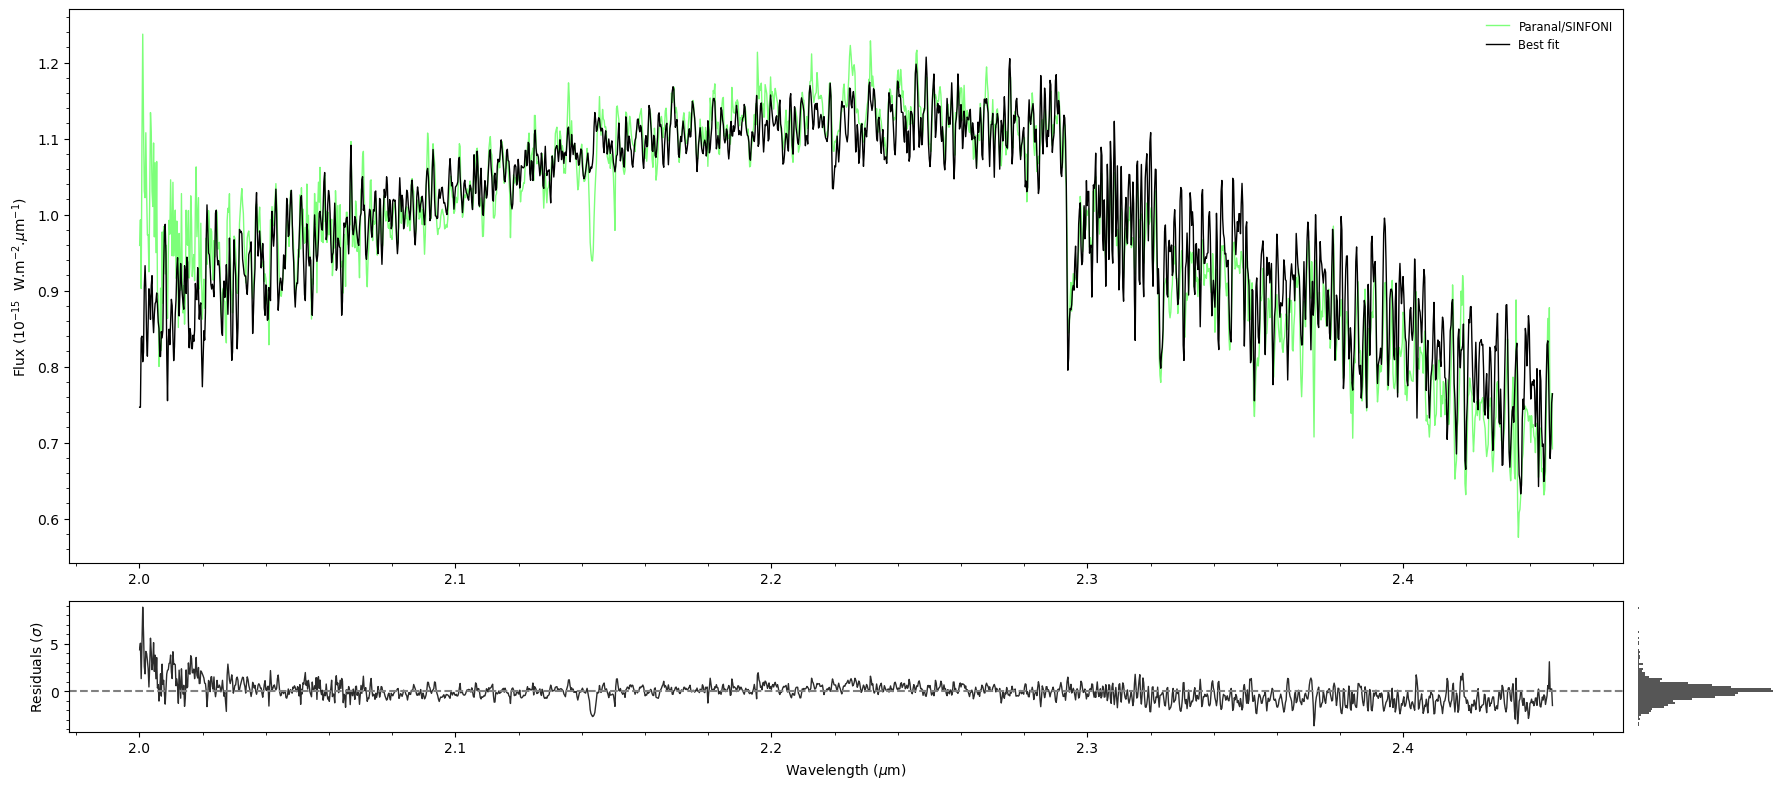

In [15]:
analysis.plot(analysis.ns.results, plot_native_model=False)
print(analysis.ns.results.summary(sigma=1))

## Section 7: Next steps

- **Tutorial 3 — HCHR mode (AF Lep b):** VLT/HiRISE at R ≈ 140,000.
  Introduces `STAR_FLUX` extension, high-contrast modeling, and vsini.
- **Tutorial 5 — Advanced plotting:** Deep-dive into every ForMoSA plot
  and how to customise it for publication. Uses these results as input.
